# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Define Settings 

In [2]:
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3188 non-null   object        
 1   full_title         3188 non-null   object        
 2   document_type      3188 non-null   object        
 3   bureaus            3188 non-null   object        
 4   description        1577 non-null   object        
 5   webpage_url        3188 non-null   object        
 6   selected_txt_urls  3188 non-null   object        
 7   all_txt_urls       3188 non-null   object        
 8   all_txt_count      3188 non-null   int64         
 9   released_on        3188 non-null   datetime64[ns]
 10  issued_on          3188 non-null   datetime64[ns]
 11  adopted            822 non-null    datetime64[ns]
 12  filename           3188 non-null   object        
 13  body_text          3188 non-null   object        
 14  body_wor

In [4]:
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    'min_released_on': df['released_on'].min(),
    'max_released_on': df['released_on'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

qc_summary

,metric,value
0,number_of_rows,3188
1,number_of_columns,17
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,min_released_on,2010-01-05 00:00:00
6,max_released_on,2026-04-30 00:00:00


In [5]:
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2207
fallback_body_like_after_front_matter,725
fallback_body_like_after_front_matter_no_city_prefix,245
fallback_body_like_after_front_matter_normal_sentence,5
fallback_after_front_matter,3
fallback_body_like_global,3


In [6]:
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,3053
no_footer_marker,83
commissioner_office_footer,23
trailing_media_contact,17
office_media_footer,11
twitter,1


## 3.2. Explore Date Variables

In [7]:
df['date'] = df['released_on']
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [8]:
def plot_doc_trend(summary_df, x_label, y_label, tick_every=None):

    cols = summary_df.columns
    period = cols[0]
    var = cols[1]
    num_of_rows = len(summary_df)

    x_pos = range(num_of_rows)

    if tick_every == None:
        tick_every = max(1, num_of_rows // 12)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])
    
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    tick_positions = list(range(0, num_of_rows, tick_every))
    
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )
    
    plt.tight_layout()
    plt.show()

In [9]:
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

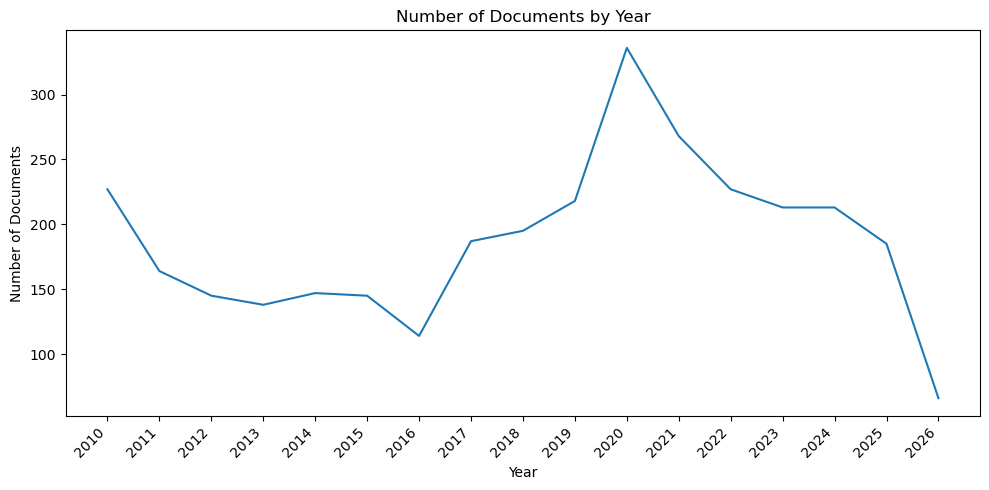

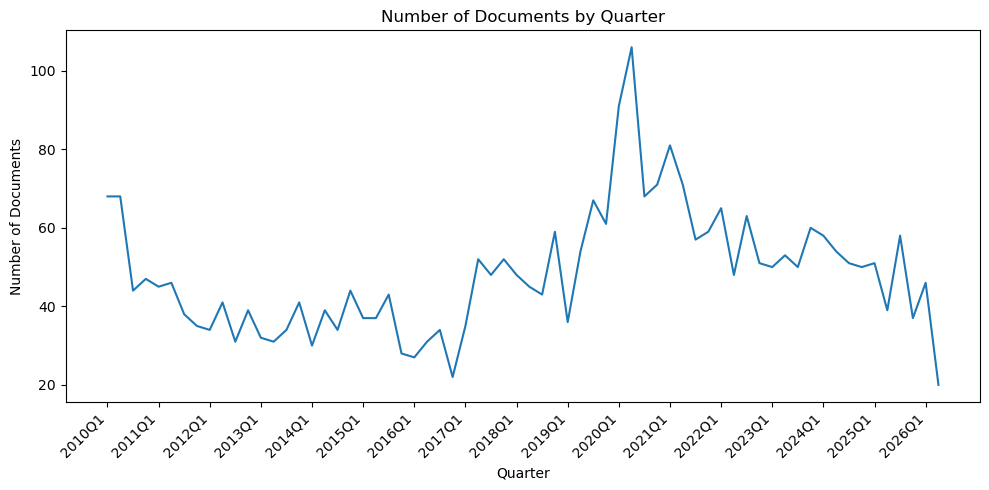

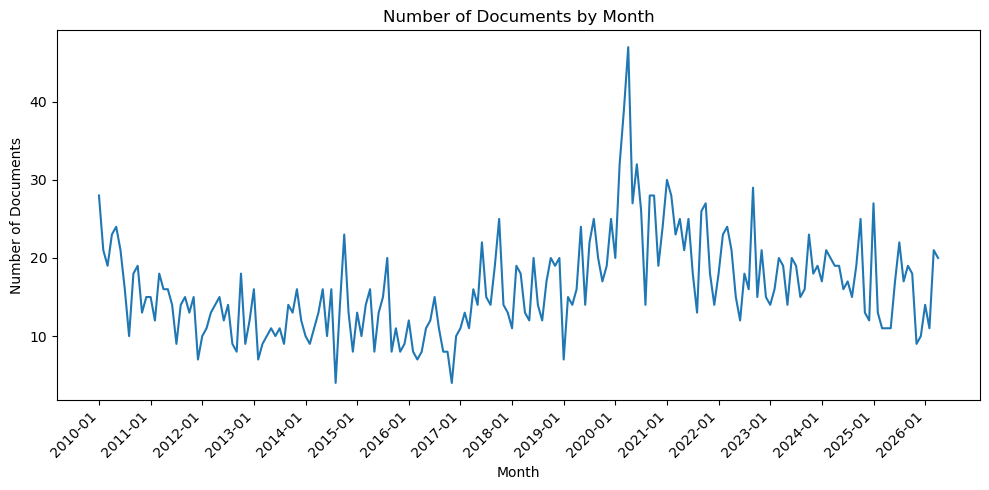

In [10]:
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 1)
plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 4)
plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 12)

In [11]:
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

word_stats_by_year

,year,count,mean,median,min,max
0,2010,227,437.859031,336.0,39,3293
1,2011,164,502.567073,363.5,90,3067
2,2012,145,525.675862,375.0,69,3390
3,2013,138,434.826087,354.5,69,4079
4,2014,147,357.993197,337.0,85,1317
5,2015,145,397.455172,357.0,71,2228
6,2016,114,385.298246,365.5,49,896
7,2017,187,339.401070,300.0,48,2239
8,2018,195,364.589744,312.0,26,1488
9,2019,218,395.527523,350.5,91,1972


In [12]:
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('n_documents').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('n_documents').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('n_documents').reset_index()

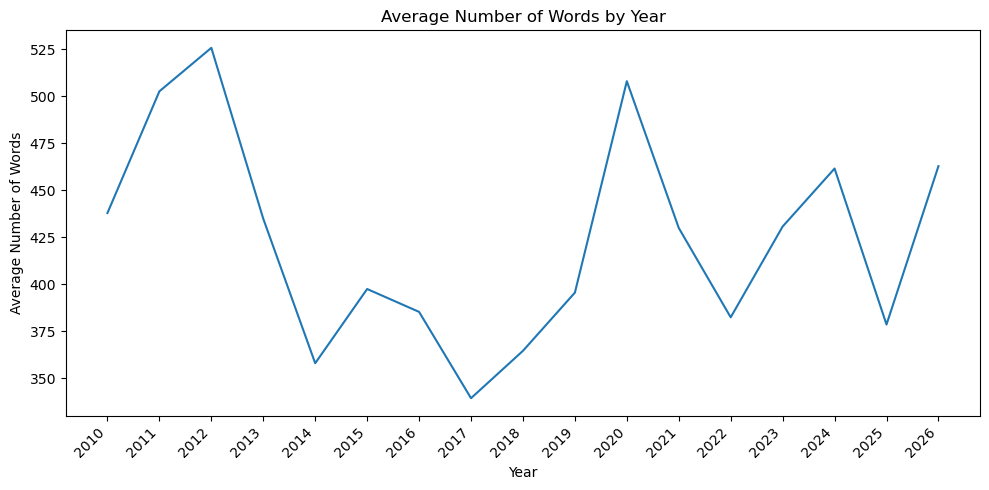

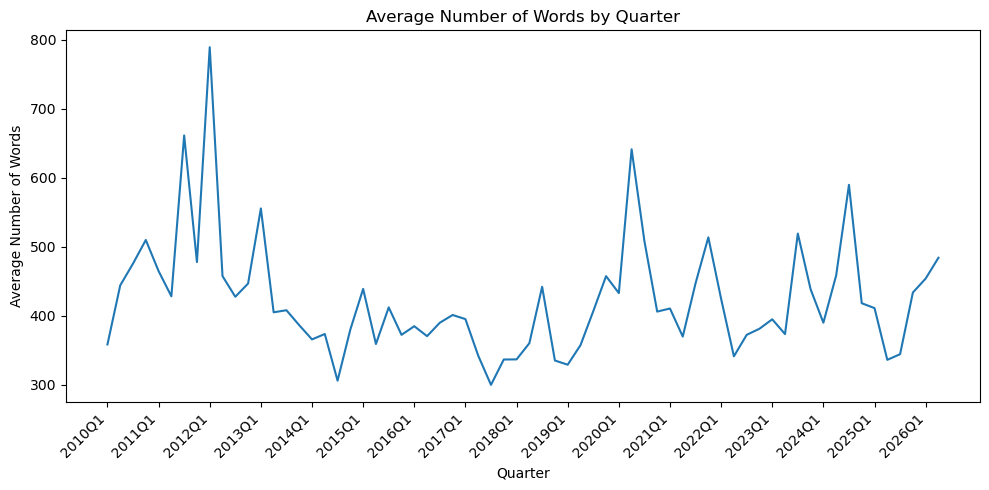

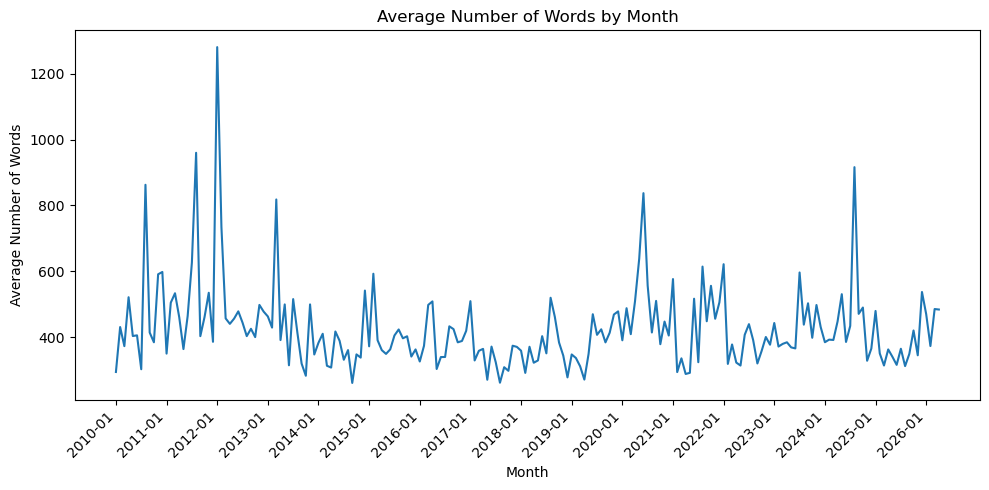

In [13]:
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words', 1)
plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words', 4)
plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words', 12)